In [12]:
import pickle
from PIL import Image
import torchvision.transforms as T
from io import BytesIO
from PIL import Image, ImageEnhance, ImageOps
import os
import torch
import contextlib
import json
from mylib import yolo_patch_softmax
from mylib import utils
import math
import numpy as np
from pycocotools.coco import COCO
import matplotlib.pyplot as plt
import skimage.io as io
from ultralytics import YOLO 
from dotenv import load_dotenv
from tqdm import tqdm  # For progress tracking
import time
load_dotenv()  # This loads from .env in the current directory

True

In [2]:
# === Load YOLO model ===
yolo_model = YOLO("yolo11x.pt")  # Swap with yolov8s.pt or yolov8x.pt as needed

In [3]:
# Initialize cuda:0 device
device = "cuda:0" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")
yolo_model = yolo_model.to(device)

Using device: cuda:0


In [4]:
# Load annotations for both datasets
cocos = {
    "train2017": COCO(os.path.join(os.getenv("COCO_DATA"), "annotations/instances_train2017.json")),
    "val2017": COCO(os.path.join(os.getenv("COCO_DATA"), "annotations/instances_val2017.json")),
}

loading annotations into memory...
Done (t=17.77s)
creating index...
index created!
loading annotations into memory...
Done (t=0.71s)
creating index...
index created!


In [5]:
# YOLO ID -- Class mapping from json file
with open('indoor_objects.json') as f:
    indoor_objects = json.load(f)
    indoor_objects = {k: v for d in indoor_objects['indoor_classes'] for k, v in d.items()}

# Bin range -- Class from json file
with open("out_bins_per_class.json") as f:
    out_bins_per_class = json.load(f)

# YOLO IDs -- COCO IDs mapping
train_coco = list(cocos.values())[0]
all_cats = train_coco.loadCats(train_coco.getCatIds())
yolo_id_to_coco_id = {i: cat["id"] for i, cat in enumerate(sorted(all_cats, key=lambda x: x["id"]))} # eg. Yolo ID 79 -> COCO ID 90

# Build lists 
yolo_ids = [int(k) for k in indoor_objects.keys()]
coco_ids = [yolo_id_to_coco_id[int(k)] for k in indoor_objects.keys()]
classes_names = [v for v in indoor_objects.values()]
classes_bins = [out_bins_per_class[v] for v in indoor_objects.values()]
num_classes = len(classes_bins)

# Print information
print("Number of classes:", num_classes,'\n')
print("YOLO IDs:", yolo_ids)
print("COCO IDs:", coco_ids)
print("Classes names:", classes_names)
print("Classes bins:", classes_bins)


Number of classes: 27 

YOLO IDs: [26, 39, 40, 41, 42, 43, 44, 45, 47, 56, 57, 58, 59, 60, 61, 62, 63, 65, 67, 68, 69, 70, 71, 73, 74, 75, 77]
COCO IDs: [31, 44, 46, 47, 48, 49, 50, 51, 53, 62, 63, 64, 65, 67, 70, 72, 73, 75, 77, 78, 79, 80, 81, 84, 85, 86, 88]
Classes names: ['handbag', 'bottle', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'apple', 'chair', 'couch', 'potted plant', 'bed', 'dining table', 'toilet', 'tv', 'laptop', 'remote', 'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'book', 'clock', 'vase', 'teddy bear']
Classes bins: [[0.0, 0.05, 0.11, 0.19, 0.33, 0.53, 0.84, 1.41, 2.44, 4.87, 99.4], [0.0, 0.06, 0.11, 0.17, 0.25, 0.37, 0.55, 0.87, 1.52, 3.39, 99.01], [0.0, 0.09, 0.17, 0.26, 0.41, 0.65, 1.03, 1.73, 3.2, 7.09, 98.2], [0.0, 0.07, 0.13, 0.22, 0.34, 0.54, 0.89, 1.55, 2.78, 5.78, 100.0], [0.0, 0.11, 0.23, 0.4, 0.62, 0.99, 1.64, 2.71, 4.88, 9.2, 99.45], [0.0, 0.04, 0.09, 0.17, 0.3, 0.55, 0.94, 1.59, 3.0, 6.7, 83.22], [0.0, 0.06, 0.12, 0.21, 0.34, 0.54, 

In [6]:
# === Helper: Get COCO split for a given image ID ===
def find_split_for_image(img_id):
    for split, coco_obj in cocos.items():
        if img_id in coco_obj.imgs:
            return split, coco_obj
    return None, None

Processing 7133 images for handbag:   0%|          | 0/7133 [00:00<?, ?image/s]

Ground truth Scale: 1.4962%
Ground truth Bin index: 7
Classes bins: [0.0, 0.05, 0.11, 0.19, 0.33, 0.53, 0.84, 1.41, 2.44, 4.87, 99.4]


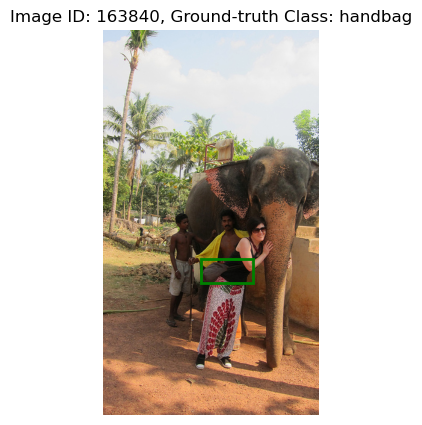

Ground truth Scale: 1.4962%
Ground truth Bin index: 7
Classes bins: [0.0, 0.05, 0.11, 0.19, 0.33, 0.53, 0.84, 1.41, 2.44, 4.87, 99.4]


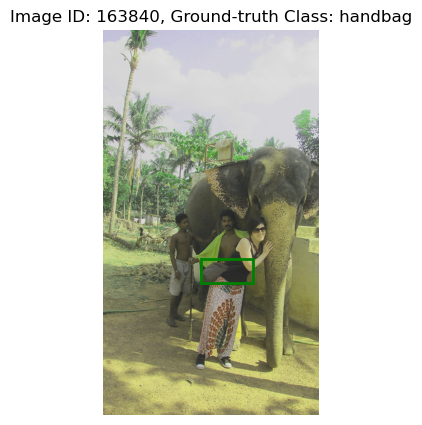

Ground truth Scale: 1.4962%
Ground truth Bin index: 7
Classes bins: [0.0, 0.05, 0.11, 0.19, 0.33, 0.53, 0.84, 1.41, 2.44, 4.87, 99.4]


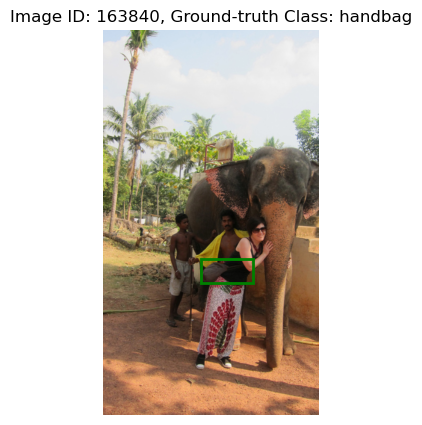

Ground truth Scale: 1.4962%
Ground truth Bin index: 7
Classes bins: [0.0, 0.05, 0.11, 0.19, 0.33, 0.53, 0.84, 1.41, 2.44, 4.87, 99.4]


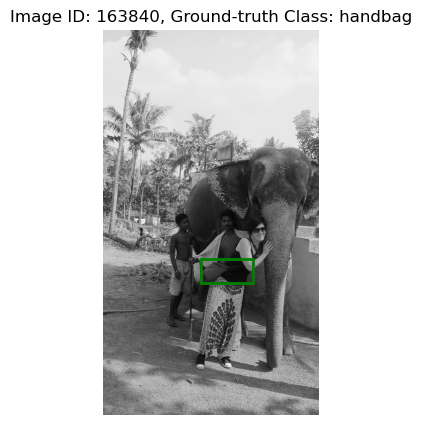

Ground truth Scale: 1.4962%
Ground truth Bin index: 7
Classes bins: [0.0, 0.05, 0.11, 0.19, 0.33, 0.53, 0.84, 1.41, 2.44, 4.87, 99.4]


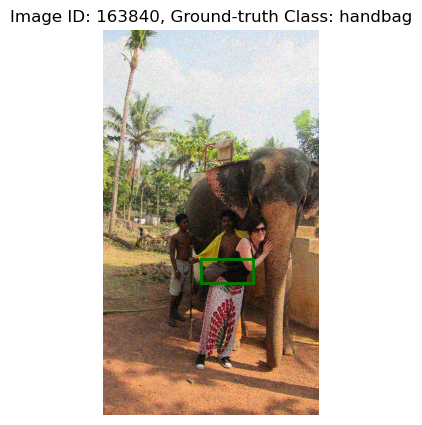

Ground truth Scale: 1.4962%
Ground truth Bin index: 7
Classes bins: [0.0, 0.05, 0.11, 0.19, 0.33, 0.53, 0.84, 1.41, 2.44, 4.87, 99.4]


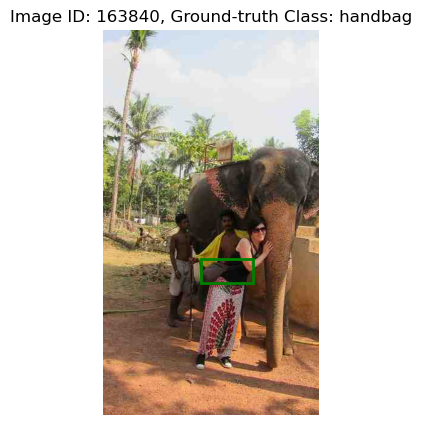

Ground truth Scale: 1.4962%
Ground truth Bin index: 7
Classes bins: [0.0, 0.05, 0.11, 0.19, 0.33, 0.53, 0.84, 1.41, 2.44, 4.87, 99.4]


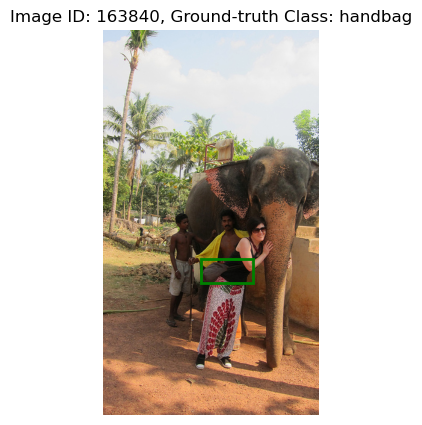

Ground truth Scale: 1.4962%
Ground truth Bin index: 7
Classes bins: [0.0, 0.05, 0.11, 0.19, 0.33, 0.53, 0.84, 1.41, 2.44, 4.87, 99.4]


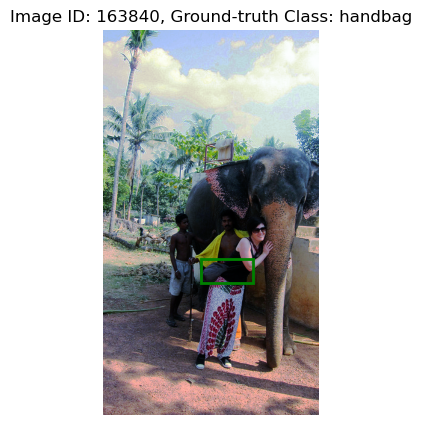

Ground truth Scale: 1.4962%
Ground truth Bin index: 7
Classes bins: [0.0, 0.05, 0.11, 0.19, 0.33, 0.53, 0.84, 1.41, 2.44, 4.87, 99.4]


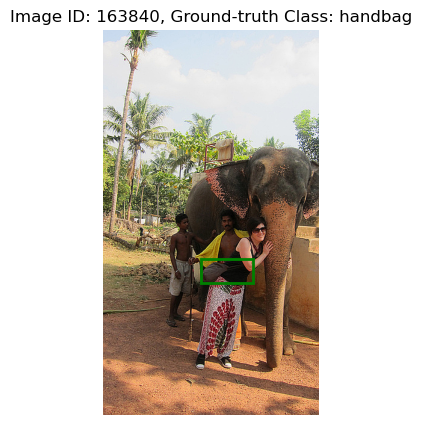

Processing 8880 images for bottle:   0%|          | 0/8880 [00:00<?, ?image/s]

Ground truth Scale: 0.1160%
Ground truth Bin index: 2
Classes bins: [0.0, 0.06, 0.11, 0.17, 0.25, 0.37, 0.55, 0.87, 1.52, 3.39, 99.01]
XYXY (corner format): (345.1, 239.7, 355.0, 278.8)
XYWH (center format): (350.1, 259.2, 9.8, 39.1)
Confidence: 0.9055, Class ID: 39, Class Name: bottle
Probability vector: ['1.207e-03', '2.915e-04', '1.057e-04', '1.630e-04', '1.603e-04', '3.481e-04', '4.589e-04', '1.633e-04', '1.326e-03', '9.875e-04', '2.183e-03', '3.816e-04', '1.138e-03', '1.505e-04', '1.456e-03', '1.941e-03', '3.728e-04', '3.167e-04', '8.948e-05', '1.058e-04', '6.254e-05', '2.454e-04', '2.085e-04', '7.506e-04', '3.673e-04', '3.028e-03', '4.028e-03', '3.386e-03', '9.042e-04', '3.851e-04', '1.881e-04', '5.356e-04', '2.623e-04', '6.419e-04', '1.495e-03', '2.701e-04', '5.361e-04', '4.059e-04', '1.646e-03', '9.055e-01', '2.192e-03', '2.954e-03', '4.663e-04', '2.244e-03', '8.111e-04', '1.234e-04', '4.644e-04', '1.827e-04', '3.326e-04', '1.858e-04', '1.793e-04', '4.373e-04', '5.405e-04', '3.

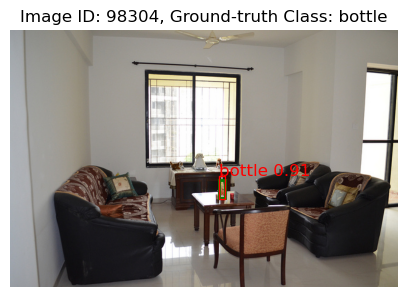

Ground truth Scale: 0.1160%
Ground truth Bin index: 2
Classes bins: [0.0, 0.06, 0.11, 0.17, 0.25, 0.37, 0.55, 0.87, 1.52, 3.39, 99.01]
XYXY (corner format): (344.9, 239.5, 355.0, 278.4)
XYWH (center format): (350.0, 258.9, 10.1, 38.9)
Confidence: 0.8833, Class ID: 39, Class Name: bottle
Probability vector: ['1.486e-03', '3.504e-04', '1.362e-04', '1.833e-04', '2.021e-04', '4.195e-04', '5.736e-04', '2.065e-04', '1.734e-03', '1.198e-03', '2.489e-03', '4.792e-04', '1.438e-03', '1.829e-04', '1.849e-03', '2.314e-03', '4.440e-04', '3.921e-04', '1.059e-04', '1.270e-04', '8.245e-05', '2.819e-04', '2.672e-04', '9.549e-04', '4.640e-04', '4.659e-03', '5.788e-03', '4.183e-03', '1.044e-03', '4.483e-04', '2.333e-04', '5.911e-04', '3.059e-04', '8.994e-04', '1.748e-03', '3.275e-04', '5.991e-04', '5.047e-04', '1.891e-03', '8.833e-01', '2.322e-03', '3.578e-03', '4.996e-04', '2.732e-03', '8.861e-04', '1.387e-04', '5.429e-04', '2.056e-04', '3.714e-04', '1.941e-04', '1.734e-04', '5.257e-04', '5.676e-04', '3

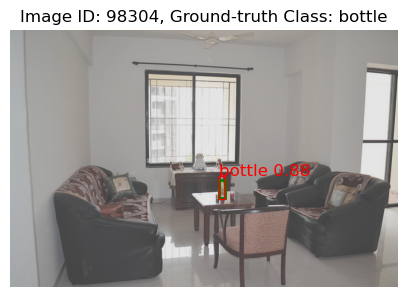

Ground truth Scale: 0.1160%
Ground truth Bin index: 2
Classes bins: [0.0, 0.06, 0.11, 0.17, 0.25, 0.37, 0.55, 0.87, 1.52, 3.39, 99.01]
XYXY (corner format): (344.3, 239.7, 354.8, 277.6)
XYWH (center format): (349.6, 258.7, 10.6, 37.9)
Confidence: 0.8287, Class ID: 39, Class Name: bottle
Probability vector: ['1.731e-03', '3.003e-04', '8.805e-05', '2.082e-04', '2.291e-04', '2.374e-04', '4.488e-04', '1.723e-04', '1.053e-03', '1.142e-03', '1.909e-03', '3.861e-04', '1.045e-03', '1.824e-04', '1.748e-03', '3.289e-03', '5.101e-04', '3.497e-04', '1.239e-04', '1.525e-04', '9.836e-05', '4.037e-04', '2.736e-04', '8.565e-04', '5.046e-04', '3.895e-03', '5.060e-03', '7.085e-03', '1.247e-03', '4.072e-04', '2.745e-04', '9.646e-04', '3.538e-04', '9.772e-04', '1.816e-03', '2.603e-04', '6.069e-04', '4.805e-04', '2.101e-03', '8.287e-01', '4.710e-03', '8.470e-03', '1.100e-03', '5.352e-03', '2.024e-03', '2.115e-04', '8.240e-04', '3.913e-04', '5.353e-04', '3.899e-04', '4.942e-04', '7.070e-04', '5.612e-04', '5

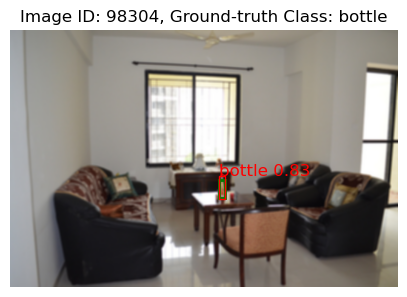

Ground truth Scale: 0.1160%
Ground truth Bin index: 2
Classes bins: [0.0, 0.06, 0.11, 0.17, 0.25, 0.37, 0.55, 0.87, 1.52, 3.39, 99.01]
XYXY (corner format): (344.5, 239.5, 355.1, 278.5)
XYWH (center format): (349.8, 259.0, 10.6, 39.0)
Confidence: 0.7471, Class ID: 39, Class Name: bottle
Probability vector: ['2.989e-03', '6.873e-04', '2.280e-04', '4.207e-04', '3.095e-04', '6.371e-04', '1.155e-03', '3.077e-04', '3.675e-03', '1.564e-03', '4.273e-03', '6.997e-04', '2.322e-03', '2.888e-04', '4.135e-03', '6.827e-03', '1.217e-03', '1.464e-03', '4.225e-04', '5.484e-04', '2.951e-04', '8.556e-04', '8.930e-04', '3.454e-03', '8.497e-04', '7.833e-03', '9.489e-03', '1.034e-02', '1.560e-03', '6.159e-04', '4.033e-04', '1.081e-03', '5.221e-04', '1.412e-03', '2.416e-03', '6.651e-04', '1.050e-03', '9.173e-04', '2.882e-03', '7.471e-01', '5.787e-03', '5.460e-03', '8.688e-04', '4.238e-03', '1.648e-03', '3.033e-04', '1.049e-03', '3.940e-04', '9.072e-04', '3.568e-04', '3.355e-04', '8.698e-04', '1.137e-03', '7

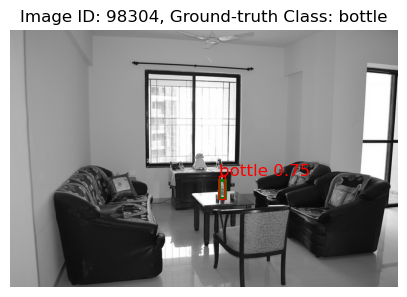

Ground truth Scale: 0.1160%
Ground truth Bin index: 2
Classes bins: [0.0, 0.06, 0.11, 0.17, 0.25, 0.37, 0.55, 0.87, 1.52, 3.39, 99.01]
XYXY (corner format): (344.9, 239.4, 355.2, 286.5)
XYWH (center format): (350.0, 262.9, 10.3, 47.0)
Confidence: 0.8677, Class ID: 39, Class Name: bottle
Probability vector: ['2.843e-03', '4.456e-04', '1.616e-04', '2.268e-04', '2.326e-04', '4.540e-04', '5.656e-04', '2.219e-04', '1.904e-03', '1.103e-03', '2.506e-03', '4.388e-04', '1.152e-03', '2.141e-04', '1.935e-03', '2.873e-03', '5.511e-04', '4.680e-04', '1.365e-04', '1.798e-04', '1.032e-04', '3.661e-04', '2.834e-04', '1.261e-03', '4.940e-04', '5.108e-03', '5.129e-03', '5.910e-03', '1.214e-03', '4.674e-04', '3.044e-04', '8.467e-04', '2.912e-04', '7.684e-04', '2.038e-03', '2.742e-04', '8.265e-04', '7.295e-04', '2.250e-03', '8.677e-01', '3.835e-03', '3.601e-03', '9.049e-04', '4.299e-03', '1.511e-03', '2.261e-04', '8.382e-04', '2.894e-04', '5.853e-04', '3.787e-04', '3.368e-04', '6.659e-04', '7.383e-04', '6

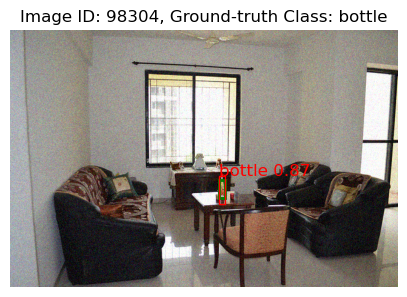

Ground truth Scale: 0.1160%
Ground truth Bin index: 2
Classes bins: [0.0, 0.06, 0.11, 0.17, 0.25, 0.37, 0.55, 0.87, 1.52, 3.39, 99.01]
XYXY (corner format): (344.5, 239.5, 355.0, 284.8)
XYWH (center format): (349.8, 262.1, 10.6, 45.3)
Confidence: 0.6742, Class ID: 39, Class Name: bottle
Probability vector: ['8.304e-03', '1.636e-03', '6.044e-04', '6.930e-04', '5.484e-04', '1.337e-03', '1.247e-03', '7.258e-04', '2.368e-03', '6.663e-03', '4.107e-03', '1.644e-03', '4.589e-03', '9.266e-04', '2.352e-03', '3.008e-03', '1.292e-03', '8.716e-04', '3.460e-04', '4.600e-04', '4.179e-04', '5.069e-04', '9.835e-04', '2.360e-03', '1.599e-03', '5.010e-03', '9.479e-03', '1.757e-02', '2.825e-03', '1.461e-03', '1.089e-03', '1.879e-03', '1.109e-03', '1.922e-03', '9.439e-03', '1.221e-03', '2.733e-03', '1.569e-03', '6.334e-03', '6.742e-01', '1.070e-02', '2.045e-02', '3.999e-03', '1.311e-02', '5.612e-03', '5.041e-04', '2.228e-03', '3.922e-04', '8.533e-04', '7.139e-04', '6.599e-04', '1.673e-03', '1.518e-03', '1

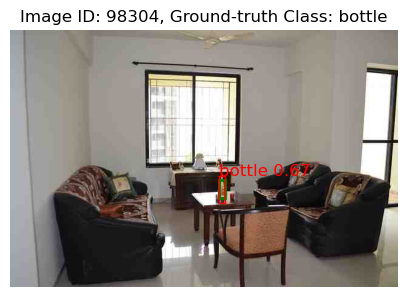

Ground truth Scale: 0.1160%
Ground truth Bin index: 2
Classes bins: [0.0, 0.06, 0.11, 0.17, 0.25, 0.37, 0.55, 0.87, 1.52, 3.39, 99.01]
XYXY (corner format): (344.9, 239.6, 355.1, 278.3)
XYWH (center format): (350.0, 258.9, 10.1, 38.7)
Confidence: 0.8618, Class ID: 39, Class Name: bottle
Probability vector: ['2.452e-03', '4.560e-04', '1.568e-04', '2.325e-04', '2.742e-04', '6.010e-04', '6.355e-04', '2.741e-04', '1.498e-03', '1.826e-03', '2.464e-03', '6.610e-04', '1.866e-03', '2.122e-04', '1.698e-03', '2.317e-03', '5.770e-04', '4.734e-04', '1.143e-04', '1.583e-04', '1.140e-04', '3.089e-04', '2.893e-04', '1.048e-03', '5.781e-04', '4.290e-03', '5.277e-03', '5.959e-03', '1.278e-03', '6.084e-04', '3.004e-04', '8.004e-04', '3.376e-04', '1.005e-03', '2.476e-03', '3.628e-04', '9.108e-04', '8.220e-04', '2.867e-03', '8.618e-01', '3.631e-03', '5.141e-03', '9.690e-04', '4.926e-03', '1.758e-03', '1.751e-04', '9.403e-04', '2.926e-04', '5.647e-04', '3.358e-04', '2.905e-04', '6.999e-04', '8.989e-04', '6

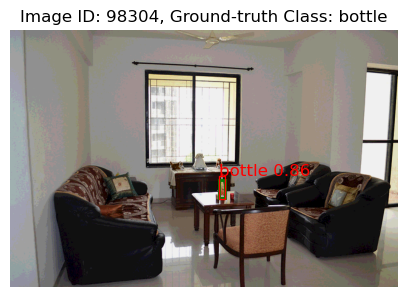

Ground truth Scale: 0.1160%
Ground truth Bin index: 2
Classes bins: [0.0, 0.06, 0.11, 0.17, 0.25, 0.37, 0.55, 0.87, 1.52, 3.39, 99.01]
XYXY (corner format): (345.4, 239.7, 355.0, 277.7)
XYWH (center format): (350.2, 258.7, 9.6, 38.0)
Confidence: 0.9440, Class ID: 39, Class Name: bottle
Probability vector: ['1.213e-03', '2.326e-04', '1.138e-04', '1.316e-04', '1.222e-04', '2.857e-04', '2.983e-04', '1.185e-04', '8.501e-04', '7.256e-04', '1.719e-03', '2.588e-04', '7.591e-04', '1.047e-04', '1.039e-03', '1.076e-03', '2.887e-04', '2.417e-04', '6.683e-05', '6.558e-05', '3.663e-05', '1.561e-04', '1.247e-04', '4.012e-04', '2.192e-04', '1.539e-03', '2.109e-03', '1.781e-03', '5.027e-04', '3.649e-04', '1.261e-04', '3.140e-04', '2.177e-04', '3.448e-04', '9.765e-04', '1.684e-04', '3.403e-04', '3.371e-04', '9.623e-04', '9.440e-01', '1.588e-03', '2.185e-03', '4.285e-04', '1.911e-03', '6.724e-04', '1.444e-04', '4.873e-04', '2.074e-04', '2.918e-04', '1.766e-04', '1.289e-04', '3.425e-04', '6.106e-04', '3.

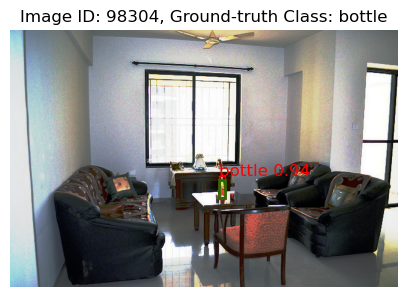

Ground truth Scale: 0.1160%
Ground truth Bin index: 2
Classes bins: [0.0, 0.06, 0.11, 0.17, 0.25, 0.37, 0.55, 0.87, 1.52, 3.39, 99.01]
XYXY (corner format): (345.0, 239.4, 355.1, 278.2)
XYWH (center format): (350.0, 258.8, 10.1, 38.8)
Confidence: 0.8777, Class ID: 39, Class Name: bottle
Probability vector: ['1.809e-03', '3.558e-04', '1.609e-04', '2.288e-04', '2.318e-04', '5.180e-04', '6.800e-04', '2.617e-04', '1.411e-03', '1.235e-03', '1.675e-03', '4.740e-04', '1.360e-03', '1.730e-04', '1.592e-03', '2.581e-03', '5.309e-04', '4.293e-04', '9.998e-05', '1.299e-04', '7.694e-05', '3.107e-04', '3.465e-04', '9.673e-04', '7.585e-04', '3.298e-03', '6.329e-03', '6.792e-03', '1.026e-03', '5.112e-04', '2.407e-04', '6.801e-04', '3.365e-04', '9.660e-04', '1.806e-03', '4.791e-04', '6.559e-04', '4.867e-04', '2.634e-03', '8.777e-01', '2.812e-03', '3.577e-03', '7.020e-04', '3.122e-03', '9.443e-04', '1.428e-04', '6.194e-04', '2.133e-04', '4.769e-04', '1.746e-04', '2.306e-04', '4.641e-04', '7.166e-04', '5

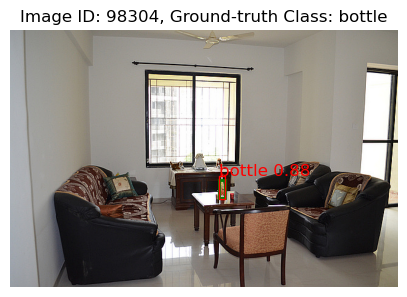

Processing 2643 images for wine glass:   0%|          | 0/2643 [00:00<?, ?image/s]

Ground truth Scale: 14.6070%
Ground truth Bin index: 9
Classes bins: [0.0, 0.09, 0.17, 0.26, 0.41, 0.65, 1.03, 1.73, 3.2, 7.09, 98.2]
XYXY (corner format): (104.8, 16.8, 215.4, 270.0)
XYWH (center format): (160.1, 143.4, 110.6, 253.2)
Confidence: 0.9067, Class ID: 40, Class Name: wine glass
Probability vector: ['8.063e-04', '9.663e-04', '8.784e-05', '1.670e-03', '9.787e-04', '7.044e-04', '3.100e-05', '3.605e-05', '3.897e-04', '9.171e-04', '2.956e-04', '2.450e-04', '4.150e-04', '2.108e-05', '1.651e-03', '8.312e-04', '6.724e-04', '1.265e-04', '5.972e-05', '1.176e-03', '7.781e-05', '6.833e-05', '5.728e-05', '3.727e-03', '2.464e-04', '8.037e-05', '3.088e-04', '2.879e-04', '7.965e-05', '4.293e-04', '3.445e-04', '4.966e-04', '6.645e-04', '9.171e-04', '2.717e-04', '1.338e-04', '3.227e-04', '2.620e-04', '4.694e-03', '3.080e-03', '9.067e-01', '1.040e-02', '2.276e-03', '3.579e-04', '5.634e-03', '1.517e-03', '8.643e-05', '4.456e-04', '1.298e-03', '2.437e-03', '2.851e-04', '2.914e-04', '3.064e-04'

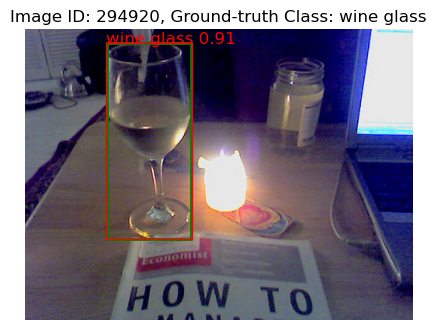

Ground truth Scale: 14.6070%
Ground truth Bin index: 9
Classes bins: [0.0, 0.09, 0.17, 0.26, 0.41, 0.65, 1.03, 1.73, 3.2, 7.09, 98.2]
XYXY (corner format): (104.8, 16.4, 214.8, 269.9)
XYWH (center format): (159.8, 143.1, 110.0, 253.6)
Confidence: 0.9021, Class ID: 40, Class Name: wine glass
Probability vector: ['9.442e-04', '1.171e-03', '9.544e-05', '1.652e-03', '1.158e-03', '7.005e-04', '3.407e-05', '4.290e-05', '4.359e-04', '8.649e-04', '3.349e-04', '2.664e-04', '4.111e-04', '2.481e-05', '1.914e-03', '8.883e-04', '6.944e-04', '1.475e-04', '7.316e-05', '1.225e-03', '9.061e-05', '7.010e-05', '6.257e-05', '4.007e-03', '2.577e-04', '9.676e-05', '3.338e-04', '2.745e-04', '7.807e-05', '4.543e-04', '3.605e-04', '4.295e-04', '6.939e-04', '8.948e-04', '2.682e-04', '1.445e-04', '3.138e-04', '2.671e-04', '4.928e-03', '2.944e-03', '9.021e-01', '1.157e-02', '2.524e-03', '3.680e-04', '5.745e-03', '1.728e-03', '1.077e-04', '4.759e-04', '1.637e-03', '3.000e-03', '2.887e-04', '3.220e-04', '3.145e-04'

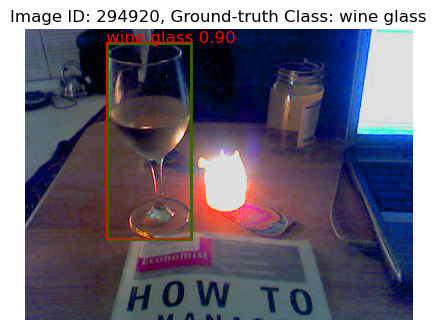

Ground truth Scale: 14.6070%
Ground truth Bin index: 9
Classes bins: [0.0, 0.09, 0.17, 0.26, 0.41, 0.65, 1.03, 1.73, 3.2, 7.09, 98.2]
XYXY (corner format): (104.4, 16.1, 215.2, 269.6)
XYWH (center format): (159.8, 142.9, 110.8, 253.5)
Confidence: 0.9059, Class ID: 40, Class Name: wine glass
Probability vector: ['7.694e-04', '9.736e-04', '8.929e-05', '1.867e-03', '1.058e-03', '7.111e-04', '3.312e-05', '3.471e-05', '4.127e-04', '9.209e-04', '2.756e-04', '2.407e-04', '4.221e-04', '2.140e-05', '1.857e-03', '7.637e-04', '6.772e-04', '1.227e-04', '5.935e-05', '1.138e-03', '7.865e-05', '6.504e-05', '6.174e-05', '3.537e-03', '2.505e-04', '8.487e-05', '2.959e-04', '3.111e-04', '7.918e-05', '4.753e-04', '3.567e-04', '5.179e-04', '7.247e-04', '1.043e-03', '2.965e-04', '1.414e-04', '3.456e-04', '2.942e-04', '5.604e-03', '2.899e-03', '9.059e-01', '9.341e-03', '2.498e-03', '3.662e-04', '6.020e-03', '1.561e-03', '9.388e-05', '4.621e-04', '1.203e-03', '2.379e-03', '2.983e-04', '2.969e-04', '3.136e-04'

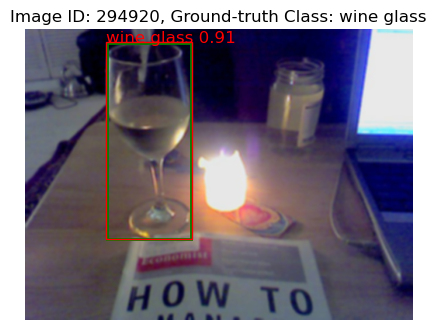

Ground truth Scale: 14.6070%
Ground truth Bin index: 9
Classes bins: [0.0, 0.09, 0.17, 0.26, 0.41, 0.65, 1.03, 1.73, 3.2, 7.09, 98.2]
XYXY (corner format): (104.7, 16.2, 215.6, 270.1)
XYWH (center format): (160.2, 143.1, 110.9, 253.9)
Confidence: 0.9211, Class ID: 40, Class Name: wine glass
Probability vector: ['7.792e-04', '8.042e-04', '6.799e-05', '1.327e-03', '8.819e-04', '6.390e-04', '2.266e-05', '2.873e-05', '3.002e-04', '6.848e-04', '2.284e-04', '2.164e-04', '3.232e-04', '1.426e-05', '1.347e-03', '7.670e-04', '5.710e-04', '1.088e-04', '5.268e-05', '1.122e-03', '6.588e-05', '5.609e-05', '4.797e-05', '3.495e-03', '2.022e-04', '5.893e-05', '2.396e-04', '2.197e-04', '5.520e-05', '3.724e-04', '2.669e-04', '3.631e-04', '6.315e-04', '7.682e-04', '2.174e-04', '1.193e-04', '2.515e-04', '2.088e-04', '4.475e-03', '2.322e-03', '9.211e-01', '9.034e-03', '1.848e-03', '2.545e-04', '4.451e-03', '1.166e-03', '6.765e-05', '3.910e-04', '1.269e-03', '2.604e-03', '2.357e-04', '2.458e-04', '2.786e-04'

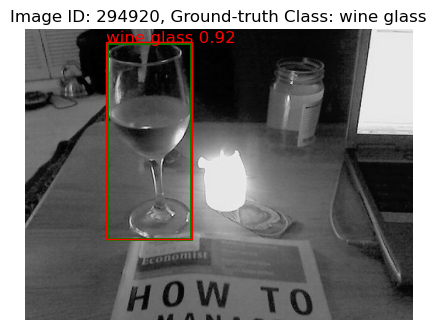

Ground truth Scale: 14.6070%
Ground truth Bin index: 9
Classes bins: [0.0, 0.09, 0.17, 0.26, 0.41, 0.65, 1.03, 1.73, 3.2, 7.09, 98.2]
XYXY (corner format): (104.6, 15.7, 215.3, 269.8)
XYWH (center format): (159.9, 142.7, 110.8, 254.1)
Confidence: 0.9215, Class ID: 40, Class Name: wine glass
Probability vector: ['7.815e-04', '8.278e-04', '6.851e-05', '1.486e-03', '9.649e-04', '4.956e-04', '2.239e-05', '2.873e-05', '2.806e-04', '6.267e-04', '2.263e-04', '1.913e-04', '3.088e-04', '1.478e-05', '1.445e-03', '7.687e-04', '5.783e-04', '1.129e-04', '5.690e-05', '1.096e-03', '6.324e-05', '5.128e-05', '4.659e-05', '3.124e-03', '2.079e-04', '6.007e-05', '2.424e-04', '2.151e-04', '5.436e-05', '3.458e-04', '2.720e-04', '3.513e-04', '5.809e-04', '7.290e-04', '2.063e-04', '1.141e-04', '2.422e-04', '1.919e-04', '4.202e-03', '2.176e-03', '9.215e-01', '8.783e-03', '1.992e-03', '2.661e-04', '4.844e-03', '1.162e-03', '7.431e-05', '3.671e-04', '1.328e-03', '2.310e-03', '2.452e-04', '2.363e-04', '2.617e-04'

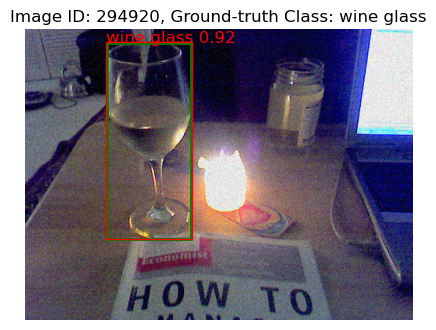

Ground truth Scale: 14.6070%
Ground truth Bin index: 9
Classes bins: [0.0, 0.09, 0.17, 0.26, 0.41, 0.65, 1.03, 1.73, 3.2, 7.09, 98.2]
XYXY (corner format): (104.9, 16.5, 215.7, 269.6)
XYWH (center format): (160.3, 143.1, 110.8, 253.1)
Confidence: 0.9083, Class ID: 40, Class Name: wine glass
Probability vector: ['8.175e-04', '9.620e-04', '8.737e-05', '1.822e-03', '9.590e-04', '6.671e-04', '3.005e-05', '3.395e-05', '3.816e-04', '8.581e-04', '2.866e-04', '2.489e-04', '3.885e-04', '2.043e-05', '1.584e-03', '6.697e-04', '5.919e-04', '1.264e-04', '6.076e-05', '1.183e-03', '8.998e-05', '6.201e-05', '5.902e-05', '3.241e-03', '2.324e-04', '7.792e-05', '2.784e-04', '2.730e-04', '6.899e-05', '4.961e-04', '3.451e-04', '4.918e-04', '7.984e-04', '1.003e-03', '3.127e-04', '1.501e-04', '3.310e-04', '2.763e-04', '5.677e-03', '2.616e-03', '9.083e-01', '1.014e-02', '2.430e-03', '3.544e-04', '6.607e-03', '1.721e-03', '9.214e-05', '4.775e-04', '1.153e-03', '2.678e-03', '3.064e-04', '3.158e-04', '3.238e-04'

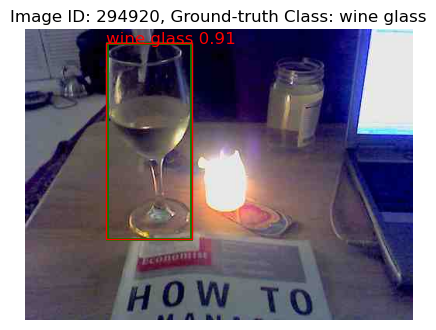

Ground truth Scale: 14.6070%
Ground truth Bin index: 9
Classes bins: [0.0, 0.09, 0.17, 0.26, 0.41, 0.65, 1.03, 1.73, 3.2, 7.09, 98.2]
XYXY (corner format): (104.8, 16.8, 215.4, 270.0)
XYWH (center format): (160.1, 143.4, 110.6, 253.2)
Confidence: 0.9067, Class ID: 40, Class Name: wine glass
Probability vector: ['8.063e-04', '9.663e-04', '8.784e-05', '1.670e-03', '9.787e-04', '7.044e-04', '3.100e-05', '3.605e-05', '3.897e-04', '9.171e-04', '2.956e-04', '2.450e-04', '4.150e-04', '2.108e-05', '1.651e-03', '8.312e-04', '6.724e-04', '1.265e-04', '5.972e-05', '1.176e-03', '7.781e-05', '6.833e-05', '5.728e-05', '3.727e-03', '2.464e-04', '8.037e-05', '3.088e-04', '2.879e-04', '7.965e-05', '4.293e-04', '3.445e-04', '4.966e-04', '6.645e-04', '9.171e-04', '2.717e-04', '1.338e-04', '3.227e-04', '2.620e-04', '4.694e-03', '3.080e-03', '9.067e-01', '1.040e-02', '2.276e-03', '3.579e-04', '5.634e-03', '1.517e-03', '8.643e-05', '4.456e-04', '1.298e-03', '2.437e-03', '2.851e-04', '2.914e-04', '3.064e-04'

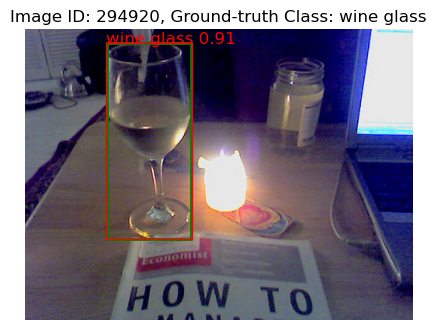

Ground truth Scale: 14.6070%
Ground truth Bin index: 9
Classes bins: [0.0, 0.09, 0.17, 0.26, 0.41, 0.65, 1.03, 1.73, 3.2, 7.09, 98.2]
XYXY (corner format): (104.1, 16.4, 214.9, 269.1)
XYWH (center format): (159.5, 142.8, 110.8, 252.7)
Confidence: 0.9135, Class ID: 40, Class Name: wine glass
Probability vector: ['7.971e-04', '9.846e-04', '6.381e-05', '1.475e-03', '9.553e-04', '5.228e-04', '2.325e-05', '2.682e-05', '3.852e-04', '5.721e-04', '2.217e-04', '2.136e-04', '2.688e-04', '1.830e-05', '1.801e-03', '7.270e-04', '5.825e-04', '1.171e-04', '6.423e-05', '1.066e-03', '7.992e-05', '5.407e-05', '5.550e-05', '3.705e-03', '2.128e-04', '7.731e-05', '2.647e-04', '2.294e-04', '5.433e-05', '4.424e-04', '3.345e-04', '3.639e-04', '6.712e-04', '9.120e-04', '2.458e-04', '1.297e-04', '2.609e-04', '2.407e-04', '5.735e-03', '1.980e-03', '9.135e-01', '9.084e-03', '2.698e-03', '3.209e-04', '6.034e-03', '1.719e-03', '9.575e-05', '4.317e-04', '1.450e-03', '3.028e-03', '2.886e-04', '3.172e-04', '2.772e-04'

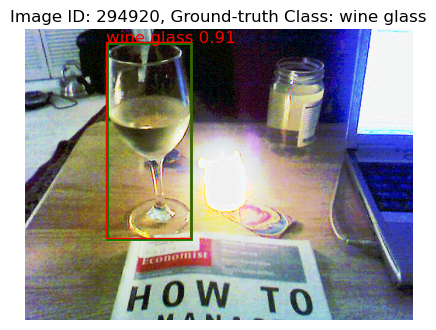

Ground truth Scale: 14.6070%
Ground truth Bin index: 9
Classes bins: [0.0, 0.09, 0.17, 0.26, 0.41, 0.65, 1.03, 1.73, 3.2, 7.09, 98.2]
XYXY (corner format): (105.0, 16.5, 214.9, 269.9)
XYWH (center format): (159.9, 143.2, 109.9, 253.4)
Confidence: 0.9079, Class ID: 40, Class Name: wine glass
Probability vector: ['8.514e-04', '1.013e-03', '8.269e-05', '1.511e-03', '9.782e-04', '6.327e-04', '2.821e-05', '3.549e-05', '3.815e-04', '8.887e-04', '3.032e-04', '2.424e-04', '3.756e-04', '2.266e-05', '1.710e-03', '7.748e-04', '6.398e-04', '1.296e-04', '6.179e-05', '1.162e-03', '8.218e-05', '6.370e-05', '5.260e-05', '3.723e-03', '2.392e-04', '8.380e-05', '3.112e-04', '2.640e-04', '7.153e-05', '4.219e-04', '3.362e-04', '4.425e-04', '6.695e-04', '8.907e-04', '2.686e-04', '1.329e-04', '3.042e-04', '2.465e-04', '4.654e-03', '2.916e-03', '9.079e-01', '1.105e-02', '2.256e-03', '3.510e-04', '5.692e-03', '1.523e-03', '8.889e-05', '4.305e-04', '1.340e-03', '2.610e-03', '2.660e-04', '3.003e-04', '2.856e-04'

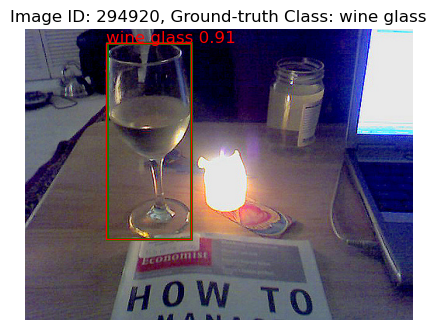

Processing 9579 images for cup:   0%|          | 0/9579 [00:00<?, ?image/s]

Ground truth Scale: 0.0260%
Ground truth Bin index: 0
Classes bins: [0.0, 0.07, 0.13, 0.22, 0.34, 0.54, 0.89, 1.55, 2.78, 5.78, 100.0]
Ground truth Scale: 0.0203%
Ground truth Bin index: 0
Classes bins: [0.0, 0.07, 0.13, 0.22, 0.34, 0.54, 0.89, 1.55, 2.78, 5.78, 100.0]
Ground truth Scale: 0.0075%
Ground truth Bin index: 0
Classes bins: [0.0, 0.07, 0.13, 0.22, 0.34, 0.54, 0.89, 1.55, 2.78, 5.78, 100.0]


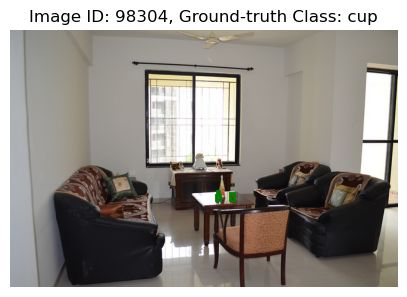

Ground truth Scale: 0.0260%
Ground truth Bin index: 0
Classes bins: [0.0, 0.07, 0.13, 0.22, 0.34, 0.54, 0.89, 1.55, 2.78, 5.78, 100.0]
Ground truth Scale: 0.0203%
Ground truth Bin index: 0
Classes bins: [0.0, 0.07, 0.13, 0.22, 0.34, 0.54, 0.89, 1.55, 2.78, 5.78, 100.0]
Ground truth Scale: 0.0075%
Ground truth Bin index: 0
Classes bins: [0.0, 0.07, 0.13, 0.22, 0.34, 0.54, 0.89, 1.55, 2.78, 5.78, 100.0]


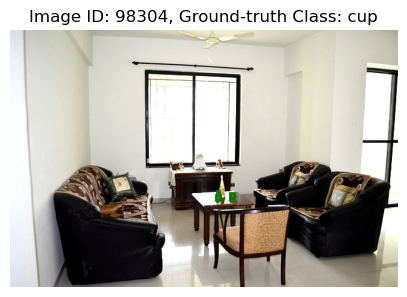

Ground truth Scale: 0.0260%
Ground truth Bin index: 0
Classes bins: [0.0, 0.07, 0.13, 0.22, 0.34, 0.54, 0.89, 1.55, 2.78, 5.78, 100.0]
Ground truth Scale: 0.0203%
Ground truth Bin index: 0
Classes bins: [0.0, 0.07, 0.13, 0.22, 0.34, 0.54, 0.89, 1.55, 2.78, 5.78, 100.0]
Ground truth Scale: 0.0075%
Ground truth Bin index: 0
Classes bins: [0.0, 0.07, 0.13, 0.22, 0.34, 0.54, 0.89, 1.55, 2.78, 5.78, 100.0]


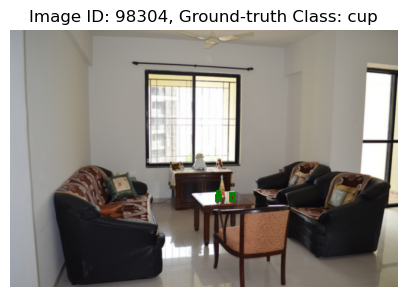

Ground truth Scale: 0.0260%
Ground truth Bin index: 0
Classes bins: [0.0, 0.07, 0.13, 0.22, 0.34, 0.54, 0.89, 1.55, 2.78, 5.78, 100.0]
Ground truth Scale: 0.0203%
Ground truth Bin index: 0
Classes bins: [0.0, 0.07, 0.13, 0.22, 0.34, 0.54, 0.89, 1.55, 2.78, 5.78, 100.0]
Ground truth Scale: 0.0075%
Ground truth Bin index: 0
Classes bins: [0.0, 0.07, 0.13, 0.22, 0.34, 0.54, 0.89, 1.55, 2.78, 5.78, 100.0]


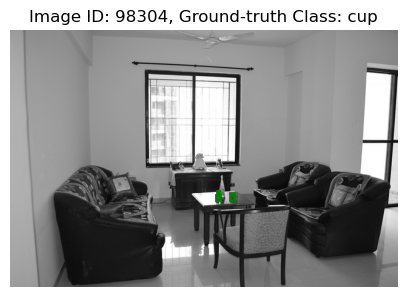

Ground truth Scale: 0.0260%
Ground truth Bin index: 0
Classes bins: [0.0, 0.07, 0.13, 0.22, 0.34, 0.54, 0.89, 1.55, 2.78, 5.78, 100.0]
XYXY (corner format): (363.1, 266.7, 370.2, 283.6)
XYWH (center format): (366.7, 275.2, 7.0, 16.9)
Confidence: 0.6812, Class ID: 41, Class Name: cup
Probability vector: ['5.578e-04', '4.093e-04', '2.039e-03', '4.448e-04', '3.035e-04', '1.860e-03', '8.605e-04', '3.291e-03', '1.356e-03', '5.780e-03', '1.593e-03', '1.600e-03', '2.191e-03', '7.301e-04', '1.016e-03', '1.181e-03', '7.749e-04', '2.253e-04', '3.628e-04', '5.272e-04', '5.463e-04', '5.084e-04', '6.670e-04', '2.292e-04', '7.149e-04', '5.734e-04', '1.566e-03', '1.539e-03', '1.208e-03', '1.153e-03', '1.660e-04', '3.759e-04', '3.606e-03', '1.037e-03', '3.526e-04', '6.990e-04', '5.796e-04', '3.071e-04', '5.203e-04', '5.301e-02', '2.829e-02', '6.812e-01', '2.723e-03', '2.769e-03', '1.989e-03', '1.317e-02', '1.113e-03', '3.145e-03', '2.877e-03', '2.879e-03', '8.720e-04', '9.323e-04', '1.002e-03', '1.587

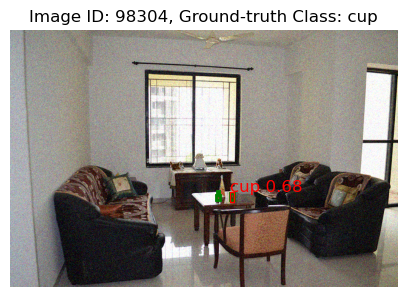

Ground truth Scale: 0.0260%
Ground truth Bin index: 0
Classes bins: [0.0, 0.07, 0.13, 0.22, 0.34, 0.54, 0.89, 1.55, 2.78, 5.78, 100.0]
Ground truth Scale: 0.0203%
Ground truth Bin index: 0
Classes bins: [0.0, 0.07, 0.13, 0.22, 0.34, 0.54, 0.89, 1.55, 2.78, 5.78, 100.0]
Ground truth Scale: 0.0075%
Ground truth Bin index: 0
Classes bins: [0.0, 0.07, 0.13, 0.22, 0.34, 0.54, 0.89, 1.55, 2.78, 5.78, 100.0]


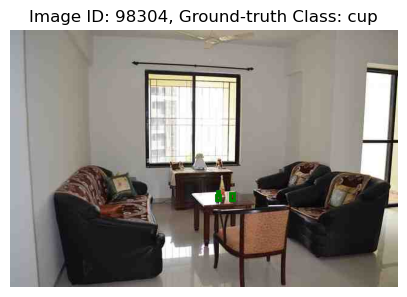

Ground truth Scale: 0.0260%
Ground truth Bin index: 0
Classes bins: [0.0, 0.07, 0.13, 0.22, 0.34, 0.54, 0.89, 1.55, 2.78, 5.78, 100.0]
Ground truth Scale: 0.0203%
Ground truth Bin index: 0
Classes bins: [0.0, 0.07, 0.13, 0.22, 0.34, 0.54, 0.89, 1.55, 2.78, 5.78, 100.0]
Ground truth Scale: 0.0075%
Ground truth Bin index: 0
Classes bins: [0.0, 0.07, 0.13, 0.22, 0.34, 0.54, 0.89, 1.55, 2.78, 5.78, 100.0]


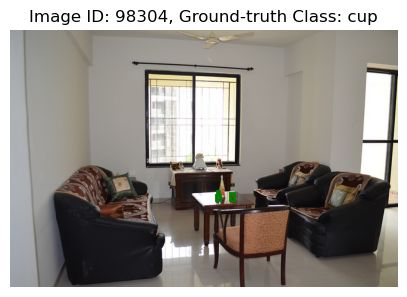

Ground truth Scale: 0.0260%
Ground truth Bin index: 0
Classes bins: [0.0, 0.07, 0.13, 0.22, 0.34, 0.54, 0.89, 1.55, 2.78, 5.78, 100.0]
Ground truth Scale: 0.0203%
Ground truth Bin index: 0
Classes bins: [0.0, 0.07, 0.13, 0.22, 0.34, 0.54, 0.89, 1.55, 2.78, 5.78, 100.0]
Ground truth Scale: 0.0075%
Ground truth Bin index: 0
Classes bins: [0.0, 0.07, 0.13, 0.22, 0.34, 0.54, 0.89, 1.55, 2.78, 5.78, 100.0]


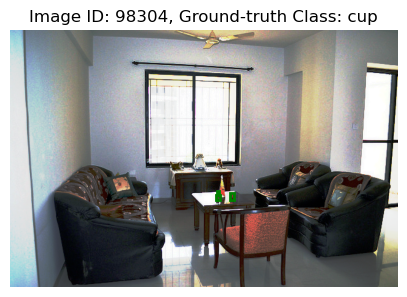

Ground truth Scale: 0.0260%
Ground truth Bin index: 0
Classes bins: [0.0, 0.07, 0.13, 0.22, 0.34, 0.54, 0.89, 1.55, 2.78, 5.78, 100.0]
Ground truth Scale: 0.0203%
Ground truth Bin index: 0
Classes bins: [0.0, 0.07, 0.13, 0.22, 0.34, 0.54, 0.89, 1.55, 2.78, 5.78, 100.0]
Ground truth Scale: 0.0075%
Ground truth Bin index: 0
Classes bins: [0.0, 0.07, 0.13, 0.22, 0.34, 0.54, 0.89, 1.55, 2.78, 5.78, 100.0]


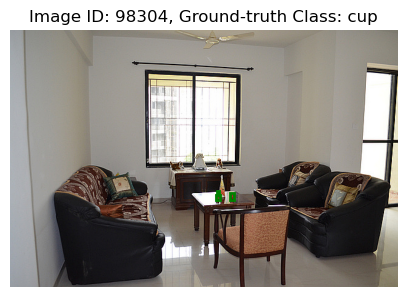

Processing 3710 images for fork:   0%|          | 0/3710 [00:00<?, ?image/s]

Ground truth Scale: 3.2992%
Ground truth Bin index: 7
Classes bins: [0.0, 0.11, 0.23, 0.4, 0.62, 0.99, 1.64, 2.71, 4.88, 9.2, 99.45]


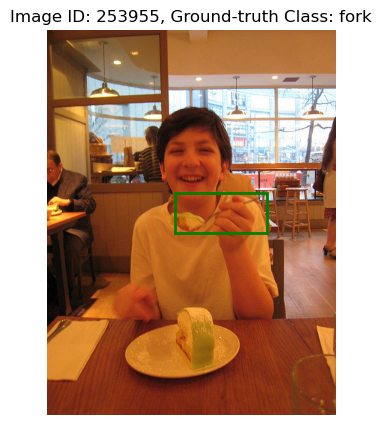

Ground truth Scale: 3.2992%
Ground truth Bin index: 7
Classes bins: [0.0, 0.11, 0.23, 0.4, 0.62, 0.99, 1.64, 2.71, 4.88, 9.2, 99.45]


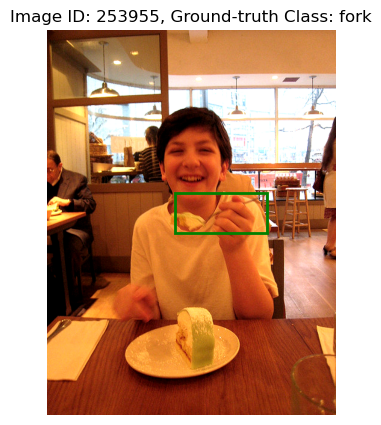

Ground truth Scale: 3.2992%
Ground truth Bin index: 7
Classes bins: [0.0, 0.11, 0.23, 0.4, 0.62, 0.99, 1.64, 2.71, 4.88, 9.2, 99.45]
XYXY (corner format): (222.1, 269.3, 347.8, 337.5)
XYWH (center format): (284.9, 303.4, 125.7, 68.1)
Confidence: 0.7509, Class ID: 42, Class Name: fork
Probability vector: ['6.727e-04', '1.905e-03', '6.123e-04', '1.201e-03', '2.102e-03', '1.187e-03', '1.912e-03', '1.171e-03', '1.906e-03', '1.522e-04', '1.670e-04', '2.076e-04', '6.972e-04', '8.387e-04', '5.889e-03', '1.074e-03', '3.745e-04', '5.489e-04', '4.906e-04', '7.044e-04', '4.049e-04', '8.708e-05', '7.544e-03', '1.691e-03', '5.962e-04', '6.833e-04', '1.440e-03', '2.609e-03', '1.818e-04', '5.236e-04', '6.540e-03', '5.611e-04', '1.822e-04', '4.264e-03', '1.940e-03', '8.890e-04', '7.650e-04', '1.447e-03', '6.431e-03', '1.302e-03', '1.073e-02', '3.866e-03', '7.509e-01', '1.135e-02', '7.821e-02', '3.103e-03', '4.060e-03', '3.638e-04', '4.173e-03', '6.561e-04', '7.311e-03', '2.238e-03', '1.287e-03', '4.83

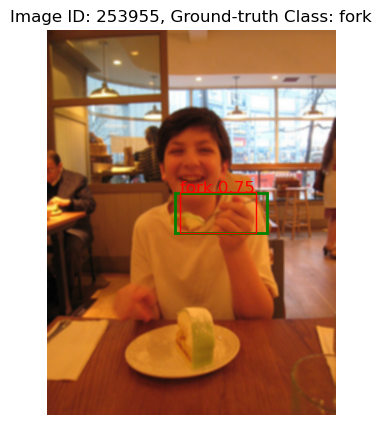

Ground truth Scale: 3.2992%
Ground truth Bin index: 7
Classes bins: [0.0, 0.11, 0.23, 0.4, 0.62, 0.99, 1.64, 2.71, 4.88, 9.2, 99.45]


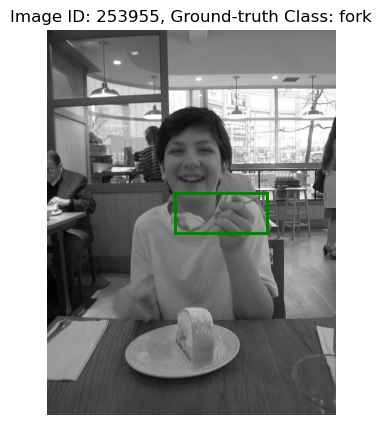

Ground truth Scale: 3.2992%
Ground truth Bin index: 7
Classes bins: [0.0, 0.11, 0.23, 0.4, 0.62, 0.99, 1.64, 2.71, 4.88, 9.2, 99.45]


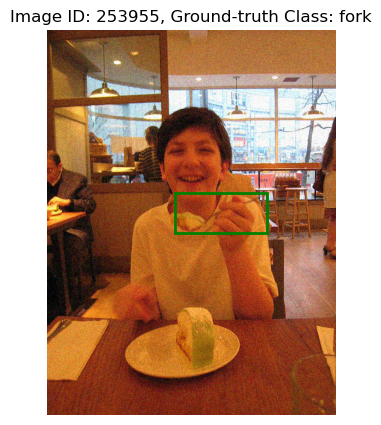

Processing 3710 images for fork:   0%|          | 0/3710 [00:01<?, ?image/s]

Ground truth Scale: 3.2992%
Ground truth Bin index: 7
Classes bins: [0.0, 0.11, 0.23, 0.4, 0.62, 0.99, 1.64, 2.71, 4.88, 9.2, 99.45]


KeyboardInterrupt: 

In [13]:
# === IoU threshold for filtering ===
IOU_THRESHOLD = 0.5

# === Data structure to store the vectors scores ===
vector_scores_struct = {cls: {b: [] for b in range(len(classes_bins[0])-1)} for cls in classes_names} 

# Loop through every class_id
for i in range(num_classes):

    # Get all image IDs for this class (from both splits)
    img_ids = []
    for split, coco_obj in cocos.items():
        img_ids += coco_obj.getImgIds(catIds=[coco_ids[i]])

    k = 0
    # Loop through each image ID
    for img_id in tqdm(img_ids, desc=f"Processing {len(img_ids)} images for {classes_names[i]}", unit="image"):
        
        # Find the split for the current image ID
        split, any_coco = find_split_for_image(img_id)
        
        # Load the image 
        img_data = any_coco.imgs[img_id]
        img_path = os.path.join(os.getenv("COCO_DATA"), split, img_data["file_name"])
        original_img = io.imread(img_path)
        
        # Check if the image is grayscale and convert to RGB if necessary
        if original_img.ndim == 2:  # grayscale
            original_img = np.stack([original_img]*3, axis=-1)


        # Augment the image
        image_set = []
        image_set.append(original_img)

        # Augmentations

        # Parse to PIL Image
        original_img = Image.fromarray(original_img)
        
        # 1 - Color Jitter
        color_jitter = T.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5, hue=0.1)
        img_color_aug = color_jitter(original_img)
        image_set.append(np.array(img_color_aug))

        # 2 - Gaussian Blur
        gaussian_blur = T.GaussianBlur(kernel_size=(5, 5), sigma=(0.5, 2.5))
        img_blur_aug = gaussian_blur(original_img)
        image_set.append(np.array(img_blur_aug))

        # 3 - Grayscale Conversion (3 channels)
        greyscale = T.Grayscale(num_output_channels=3)
        img_greyscale_aug = greyscale(original_img)
        image_set.append(np.array(img_greyscale_aug))

        # 4 - Gaussian Noise
        def add_gaussian_noise(pil_img, std=10):
            arr = np.array(pil_img).astype(np.float32)
            noise = np.random.normal(0, std, arr.shape)
            noisy_arr = np.clip(arr + noise, 0, 255).astype(np.uint8)
            return Image.fromarray(noisy_arr)

        img_noise_aug = add_gaussian_noise(original_img, std=15)
        image_set.append(np.array(img_noise_aug))

        # 5 - JPEG Compression
        def apply_jpeg_compression(pil_img, quality=25):
            buffer = BytesIO()
            pil_img.save(buffer, format="JPEG", quality=quality)
            return Image.open(buffer)

        img_jpeg_aug = apply_jpeg_compression(original_img, quality=25)
        image_set.append(np.array(img_jpeg_aug))

        # 6 - Posterize
        posterize = T.RandomPosterize(bits=4)
        img_posterize_aug = posterize(original_img)
        image_set.append(np.array(img_posterize_aug))

        # 7 - Equalize
        img_equalized_aug = ImageOps.equalize(original_img)
        image_set.append(np.array(img_equalized_aug))

        # 8 - Sharpness Adjustment
        def adjust_sharpness(pil_img, factor=2.0):
            enhancer = ImageEnhance.Sharpness(pil_img)
            return enhancer.enhance(factor)

        img_sharp_aug = adjust_sharpness(original_img, factor=2.5)
        image_set.append(np.array(img_sharp_aug))

        # Load annotations for the image
        ann_ids = any_coco.getAnnIds(imgIds=img_id, catIds=[coco_ids[i]], iscrowd=None)
        anns = any_coco.loadAnns(ann_ids)

        for img in image_set:

            # Prediction
            results = yolo_model.predict(source=img, device='cuda:0', conf=0.25, iou=0.45, verbose=False, max_det=100)
            
            # Unpack results
            result = results[0] # One image, one result
            xyxy = result.boxes.xyxy
            xywh = result.boxes.xywh
            conf = result.boxes.conf
            cls = result.boxes.cls
            prob_vectors = result.boxes.data[:, 6:]  # Probability vectors for each class

            # Plot the image
            plt.figure(figsize=(5, 5))
            plt.imshow(img)
            plt.axis('off')
            plt.title(f"Image ID: {img_id}, Ground-truth Class: {classes_names[i]}")

            # Loop ground truth annotations
            for ann in anns:
                bbox = ann["bbox"]
                x1_gt, y1_gt, w_gt, h_gt = bbox
                x2_gt = x1_gt + w_gt
                y2_gt = y1_gt + h_gt

                # Compute the scale of ground truth bounding box compared to whole image
                scale_gt = w_gt * h_gt / (img.shape[0] * img.shape[1])*100
                print(f"Ground truth Scale: {scale_gt:.4f}%")

                # Compute bin index
                bin_idx = utils.bin_index(scale_gt, classes_bins[i])

                print(f"Ground truth Bin index: {bin_idx}")
                print("Classes bins:", classes_bins[i])

                # Plot ground truth boxes
                plt.gca().add_patch(plt.Rectangle((x1_gt, y1_gt), w_gt, h_gt, fill=False, edgecolor="green", linewidth=2))

                # Loop through every detection
                for box_xyxy, box_xywh, c, cl, prob_v in zip(xyxy, xywh, conf, cls, prob_vectors):
                    x1, y1, x2, y2 = box_xyxy.tolist()
                    cx, cy, w, h = box_xywh.tolist()
                    confidence = c.item()
                    class_id = int(cl.item()) 
                    prob_vector = prob_v.tolist()

                    # Compute IoU
                    IoU = utils.compute_iou([x1, y1, x2, y2], [x1_gt, y1_gt, x2_gt, y2_gt])

                    # Check if IoU is above the threshold
                    if IoU > IOU_THRESHOLD:

                        # Add vector probability to the corresponding bin
                        vector_scores_struct[classes_names[i]][bin_idx].append(prob_vector)

                        # Print results
                        print(f"XYXY (corner format): ({x1:.1f}, {y1:.1f}, {x2:.1f}, {y2:.1f})")
                        print(f"XYWH (center format): ({cx:.1f}, {cy:.1f}, {w:.1f}, {h:.1f})")
                        print(f"Confidence: {confidence:.4f}, Class ID: {class_id}, Class Name: {yolo_model.names[class_id]}")
                        print(f"Probability vector: {[f'{x:.3e}' for x in prob_vector]}")
                        print(f"IoU: {IoU:.4f}")
                        print("---")

                        # Plot predicted boxes
                        plt.gca().add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, edgecolor="red", linewidth=1))
                        plt.text(x1, y1, f"{yolo_model.names[class_id]} {confidence:.2f}", color="red", fontsize=12)
                    
            plt.show()

            # Increment
            k +=1

        if k > 5:
            break


In [ ]:
# Save to pickle
with open("vector-scores-struct-augmented.pkl", "wb") as f:
    pickle.dump(vector_scores_struct, f)

In [ ]:
# Convert the vector scores structure to numpy arrays
for cls in vector_scores_struct:
    for b in vector_scores_struct[cls]:
        vector_scores_struct[cls][b] = np.vstack(vector_scores_struct[cls][b]) if vector_scores_struct[cls][b] else np.empty((0, 80))

In [ ]:
# Print the number of vectors in each bin
for cls in vector_scores_struct:
    for b in vector_scores_struct[cls]:
        count = len(vector_scores_struct[cls][b]) if isinstance(vector_scores_struct[cls][b], list) else vector_scores_struct[cls][b].shape[0]
        print(f"{cls} - bin {b}: {count} vectors")


In [ ]:
# Print the whole structure
print(vector_scores_struct)